In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from evo.dataset import CherriesDataset
from evo.tensor import collate_list_of_dicts
from evo.antibody import compute_region_masks_batch

In [ ]:
data_dir = Path("/scratch/users/milind_jagota/bcr/data/heavylight/peint/edges_joint")
family = "d1"
data_path = data_dir / f"{family}.txt"
assert data_path.exists(), f"Data file {data_path} does not exist."

In [ ]:
dataset = CherriesDataset(data_path, cache_indices=False)
timesteps = [dataset[i][2] for i in range(len(dataset))]

In [ ]:
from collections import Counter
same_length_seqs = [len(x) == len(y) for x, y, _ in dataset]
print(Counter(same_length_seqs))

In [ ]:
fig, ax = plt.subplots()
sns.histplot(data=timesteps, bins=30, ax=ax)
ax.set_yscale("log")
plt.show()

In [ ]:
# Take a look at the hamming distance distribution between parent child pairs
dists = []
for i in range(len(dataset)):
    x, y, _ = dataset[i]
    if len(x) == len(y):
        dists.append(np.sum(x != y))

print(Counter(dists))

In [ ]:
df = pd.read_csv("../data/wyatt/wyatt-10x-1p5m_fs-all-prank_paired-merged_pcp_2025-06-24.csv")
df = df[df['sample_id'] == family]
timesteps = df['branch_length']
# timesteps = df['distance']

In [ ]:
fig, ax = plt.subplots()
sns.histplot(data=timesteps, bins=30, ax=ax)
ax.set_yscale("log")
plt.show()

## Count number of mutations for each site in the jaffe donor 4 dataset

In [3]:
def hamming_distance(seq1, seq2):
    """Compute the Hamming distance between two sequences."""
    if len(seq1) != len(seq2):
        raise ValueError("Sequences must be of equal length")
    return sum(el1 != el2 for el1, el2 in zip(seq1, seq2))

In [33]:
# data_file = Path("/accounts/projects/yss/stephen.lu/peint-workspace/main/data/wyatt/subs/edges_heavy/aa/d4.txt")
data_file = Path("/accounts/projects/yss/stephen.lu/peint-workspace/main/data/wyatt/subs/edges_light/aa/d4.txt")
dataset = CherriesDataset(data_file, cache_indices=False)

In [34]:
xs = []
mutation_masks = []
branch_lengths = []

for x, y, t in tqdm(dataset):
    mut_mask = [el1 != el2 for el1, el2 in zip(x, y)]
    mutation_masks.append(mut_mask)
    branch_lengths.append(t)
    xs.append(x)

100%|█████████████████████████████████████████████████████████████████████████████████| 60403/60403 [00:01<00:00, 39636.51it/s]


In [35]:
region_masks = compute_region_masks_batch(sequences=xs, raise_on_error=True)
region_masks = collate_list_of_dicts(region_masks, region_masks[0].keys(), constant_value=False)

Computing masks: 100%|██████████████████████████████████████████████████████████████████| 60403/60403 [02:28<00:00, 407.18it/s]


In [36]:
mutation_rates_by_region = {}

for i in tqdm(range(len(mutation_masks))):
    mut_mask = mutation_masks[i]
    br_len = branch_lengths[i]
    reg_masks = {region: region_masks[region][i] for region in region_masks}
    # Now you can analyze mut_mask, br_len, and reg_masks as needed
    for region, mask in reg_masks.items():
        num_positions = sum(mask)
        if num_positions == 0:
            continue
        if len(mut_mask) != len(mask):
            mask = mask[:len(mut_mask)]
        num_mutations = sum(m and r for m, r in zip(mut_mask, mask))
        rate = num_mutations / (num_positions * br_len) if br_len > 0 else 0
        # rate = num_mutations / num_positions
        if region not in mutation_rates_by_region:
            mutation_rates_by_region[region] = []
        mutation_rates_by_region[region].append(rate)

100%|██████████████████████████████████████████████████████████████████████████████████| 60403/60403 [00:18<00:00, 3352.66it/s]


In [37]:
# print mean and std of mutation rates by region
for region, rates in mutation_rates_by_region.items():
    mean_rate = np.mean(rates)
    std_rate = np.std(rates)
    print(f"Region: {region}, Mean Mutation Rate: {mean_rate:.6f}, Std Dev: {std_rate:.6f}")

Region: FR1, Mean Mutation Rate: 0.017643, Std Dev: 0.312406
Region: CDR1, Mean Mutation Rate: 0.097590, Std Dev: 0.226326
Region: FR2, Mean Mutation Rate: 0.032508, Std Dev: 0.080940
Region: CDR2, Mean Mutation Rate: 0.090257, Std Dev: 0.334764
Region: FR3, Mean Mutation Rate: 0.023211, Std Dev: 0.045399
Region: CDR3, Mean Mutation Rate: 0.070116, Std Dev: 0.169084
Region: FR4, Mean Mutation Rate: 0.019709, Std Dev: 0.081506
Region: CDR_overall, Mean Mutation Rate: 0.082328, Std Dev: 0.121570
Region: FR_overall, Mean Mutation Rate: 0.023008, Std Dev: 0.094316


In [38]:
mut_rates_df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in mutation_rates_by_region.items()]))
mut_rates_df = mut_rates_df.melt(var_name='Region', value_name='Mutation Rate')
mut_rates_df.head()

,Region,Mutation Rate
0,FR1,0.044236
1,FR1,0.000000
2,FR1,0.074189
3,FR1,0.000000
4,FR1,0.011175


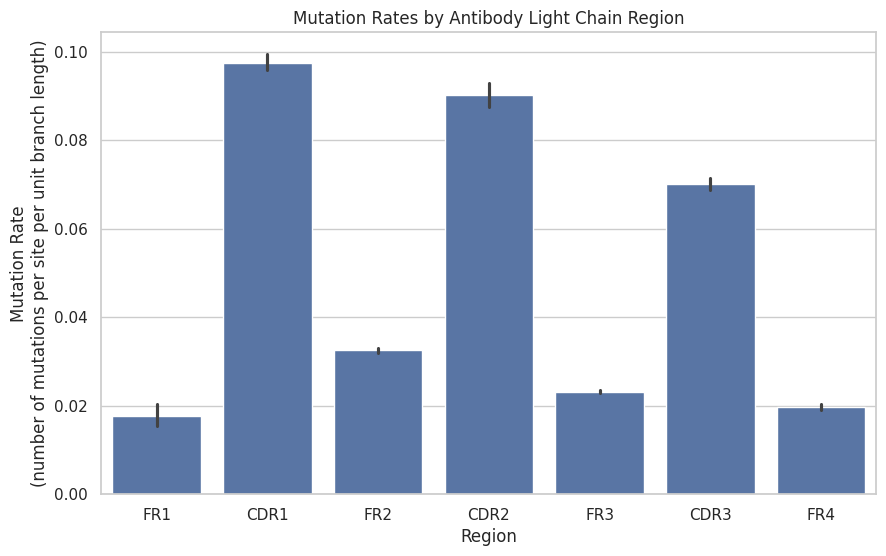

In [39]:
# barplot the mutation rates by region with 95% ci
blacklist_regions = ['CDR_overall', 'FR_overall']
data = mut_rates_df[~mut_rates_df['Region'].isin(blacklist_regions)]

sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Region', y='Mutation Rate', data=data, errorbar=('ci', 95))
ax.set_title('Mutation Rates by Antibody Light Chain Region')
ax.set_ylabel('Mutation Rate\n(number of mutations per site per unit branch length)')
plt.show()